importing all req librares

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

selecting all three columns

In [19]:
df=pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


applying K-Mean

In [20]:
features = df[["Age","Annual Income (k$)", "Spending Score (1-100)"]]
scaler = StandardScaler()
features = scaler.fit_transform(features)

printing all clusters centres

print(df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)",
    "Cluster"
]].head(20))

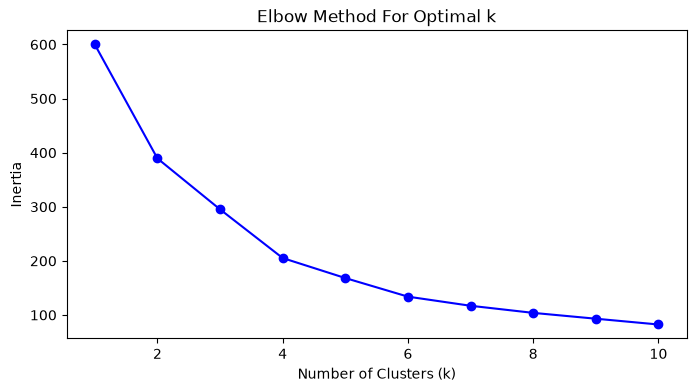

In [21]:
inertia = []
k_range = range(1, 11)

for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(features)
  inertia.append(kmeans.inertia_)


plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker="o", linestyle="-", color="b")
plt.title("Elbow Method For Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

In [22]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(features)

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

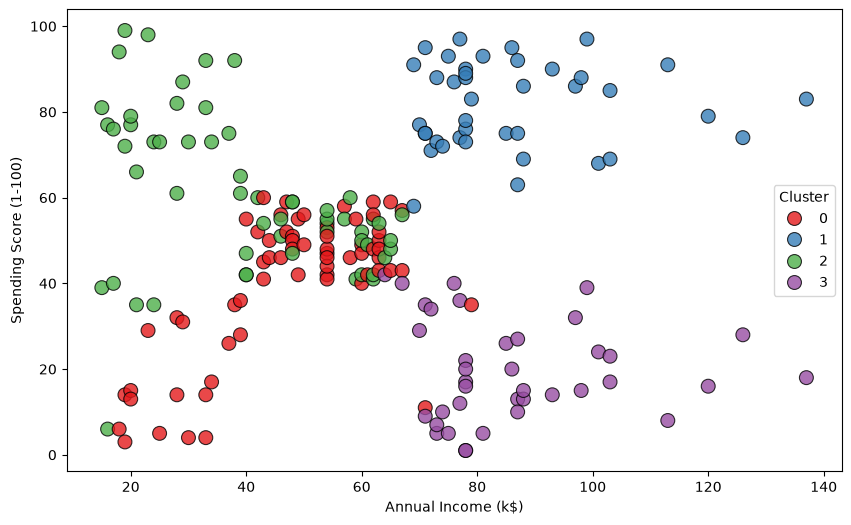

In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    data=df,
    palette="Set1",
    s=100,
    alpha=0.8,
    edgecolor="k",
)

centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=300,
    c="yellow",
    marker="X",
    edgecolor="black",
    label="Centroids",
)

plt.title("Customer Segments (K-Means Clustering)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()